# 02a — Prompt Engineering Avanzado

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque2/02a-prompt-engineering.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> Este tema forma parte del **Bloque 2 — Orquestación**. Se recomienda
> haber completado el [Bloque 1](../bloque1/01-fundamentos.qmd) primero.

In [ ]:
!pip install -q openai python-dotenv

In [ ]:
import os
"""
Setup compartido para la API key de Llamus en todos los notebooks.
Inyectado en cada .qmd/.ipynb vía scripts/sync_setup_keys.sh (pre-render).

Orden de resolución:
  1. .env local (python-dotenv)
  2. os.environ ya configurado externamente
  3. Google Colab userdata: secret "LLAMUS_API_KEY" (preferente) o "LLM_API_KEY"

Las celdas posteriores pueden leer la key con os.environ.get("LLM_API_KEY").
"""

import os


def _load_llm_api_key():
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass

    if not os.getenv("LLM_API_KEY"):
        try:
            from google.colab import userdata
            for name in ("LLAMUS_API_KEY", "LLM_API_KEY"):
                try:
                    value = userdata.get(name)
                    if value:
                        os.environ["LLM_API_KEY"] = value
                        break
                except Exception:
                    continue
        except ImportError:
            pass


_load_llm_api_key()

if os.getenv("LLM_API_KEY"):
    print("✓ LLM_API_KEY cargada.")
else:
    print("⚠️  LLM_API_KEY no encontrada.")
    print("    • Local: crea un archivo .env con LLM_API_KEY=tu_clave")
    print("    • Colab: añade un Secret 🔑 con nombre 'LLAMUS_API_KEY'")

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import json
print("Librerías cargadas correctamente.")

In [ ]:
from openai import OpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

if not LLM_KEY:
    print("⚠️  Crea un archivo .env en la raíz del proyecto con:\n    LLM_API_KEY=tu_api_key\n    Las celdas siguientes mostrarán este mensaje hasta que configures la clave.")
else:
    client = OpenAI(base_url=LLM_URL, api_key=LLM_KEY)

    # Utilidad para parsear JSON que puede venir envuelto en ```json ... ```
    def parse_json_response(content: str) -> dict:
        content = content.strip()
        if content.startswith("```"):
            content = content.split("```", 1)[1]
            if "```" in content:
                content = content.rsplit("```", 1)[0]
            content = content.strip()
            if content.startswith("json"):
                content = content[4:].strip()
        return json.loads(content)

    print("✅ Cliente OpenAI configurado. Las celdas de ejemplo funcionarán correctamente.")

## Prompt Engineering Avanzado

### ¿Qué es un prompt?

Un **prompt** es la instrucción textual que le damos a un LLM. Piensa en
ello como la pregunta o la orden que le das a un asistente muy capaz
pero muy literal: si la instrucción es ambigua, la respuesta será
imprecisa. Si es clara y con contexto, la respuesta será mucho mejor.

El Prompt Engineering consiste en diseñar estas instrucciones de forma
sistemática para obtener respuestas fiables, estructuradas y útiles, no
solo “texto bonito”.

<figure id="fig-ciclo-prompt">
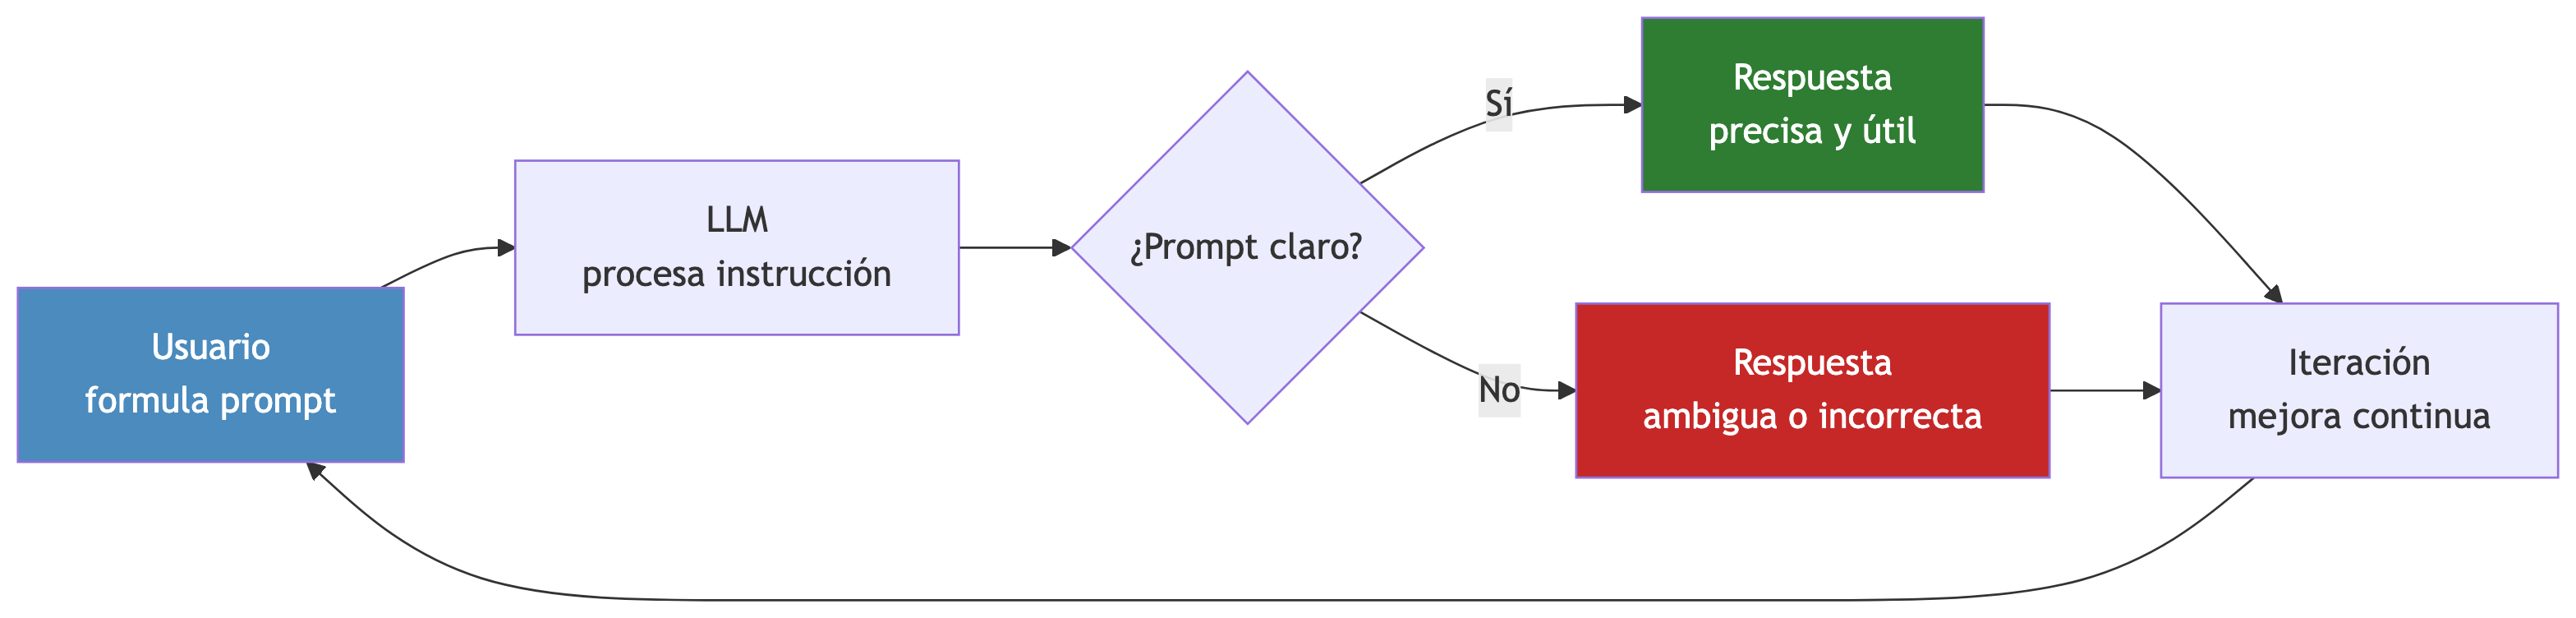
<figcaption>Figure 1</figcaption>
</figure>

### Primer contacto: llamada a un LLM

Antes de profundizar, veamos cómo invocar un LLM desde Python con la API
de OpenAI (compatible con Llamus US, Ollama local, etc.):

In [ ]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    respuesta = client.chat.completions.create(
        model="mlx-community/Qwen3.6-35B-A3B-8bit",
        messages=[{"role": "user", "content": "Explica qué es la desviación estándar en una frase."}]
    )
    print(respuesta.choices[0].message.content)

Este es el patrón base para todo lo que veremos: `model` + `messages` →
respuesta. Los `messages` pueden tener varios roles:

| Rol | Propósito | Ejemplo |
|------------------------|------------------------|------------------------|
| `system` | Instrucción global de comportamiento | “Eres un analista de datos experto” |
| `user` | Pregunta o instrucción del usuario | “Analiza este CSV…” |
| `assistant` | Respuestas previas del modelo (historial) | “La media es 42.3…” |

Table 1: Roles de los mensajes en la API de chat

### Few-shot prompting

El **few-shot** consiste en incluir ejemplos dentro del prompt para que
el modelo entienda exactamente qué formato y estilo esperamos. Es como
enseñarle con el ejemplo.

In [ ]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    prompt_few_shot = """
    Clasifica el sentimiento de cada frase como POSITIVO, NEGATIVO o NEUTRAL.

    Ejemplos:
    Frase: "El producto llegó roto y la atención fue pésima" → NEGATIVO
    Frase: "Todo perfecto, entrega rápida y bien embalado" → POSITIVO
    Frase: "El paquete llegó ayer por la tarde" → NEUTRAL

    Ahora clasifica:
    Frase: "El diseño es bonito pero la batería no dura nada"
    """

    respuesta = client.chat.completions.create(
        model="mlx-community/Qwen3.6-35B-A3B-8bit",
        messages=[{"role": "user", "content": prompt_few_shot}]
    )
    print(respuesta.choices[0].message.content)

**¿Por qué funciona?** Los LLMs son excelentes reconociendo patrones. Al
darles 2-3 ejemplos, el modelo “aprende” el patrón en contexto
(*in-context learning*) sin necesidad de fine-tuning.

> **Regla de oro del few-shot**
>
> - 2-3 ejemplos suelen bastar
> - Los ejemplos deben cubrir los casos extremos (edge cases)
> - Mantén consistencia exacta en el formato de los ejemplos

### Zero-shot vs Few-shot vs One-shot

| Estrategia | Ejemplos en el prompt | Cuándo usarlo |
|------------------------|------------------------|------------------------|
| **Zero-shot** | 0 — solo la instrucción | Tareas sencillas, modelos muy capaces |
| **One-shot** | 1 ejemplo | Cuando necesitas mostrar el formato exacto |
| **Few-shot** | 2-5 ejemplos | Tareas complejas, formatos muy específicos |

Table 2: Comparativa de estrategias de prompting por número de ejemplos

In [ ]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    # ZERO-SHOT: sin ejemplos
    respuesta_zero = client.chat.completions.create(
        model="mlx-community/Qwen3.6-35B-A3B-8bit",
        messages=[{"role": "user", "content": "Traduce al inglés: 'El gato está en el tejado'"}]
    )

    # ONE-SHOT: un ejemplo
    respuesta_one = client.chat.completions.create(
        model="mlx-community/Qwen3.6-35B-A3B-8bit",
        messages=[{"role": "user", "content": """
    Traduce español → inglés.
    Ejemplo: "Hola mundo" → "Hello world"
    Ahora traduce: "El gato está en el tejado"
    """}]
    )

    print("Zero-shot:", respuesta_zero.choices[0].message.content)
    print("One-shot:", respuesta_one.choices[0].message.content)

### Chain-of-Thought (CoT)

El **Chain-of-Thought** consiste en pedir al modelo que razone paso a
paso antes de dar la respuesta final. La clave está en añadir algo como
*“pensemos paso a paso”* o incluir ejemplos donde se muestra el
razonamiento.

In [ ]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    problema = """
    Un tren sale de Madrid a las 08:00 hacia Barcelona (620 km) a 120 km/h.
    Otro tren sale de Barcelona a las 09:00 hacia Madrid a 150 km/h.
    ¿A qué hora se cruzan?
    """

    prompt_cot = f"""
    {problema}

    Resuelve paso a paso:
    1. Calcula cuánto ha avanzado el primer tren cuando sale el segundo
    2. Calcula la distancia restante entre ambos en ese momento
    3. Calcula el tiempo hasta que se cruzan
    4. Suma el tiempo a la hora de salida
    """

    respuesta_cot = client.chat.completions.create(
        model="mlx-community/Qwen3.6-35B-A3B-8bit",
        messages=[{"role": "user", "content": prompt_cot}]
    )
    print(respuesta_cot.choices[0].message.content)

<figure id="fig-cot">
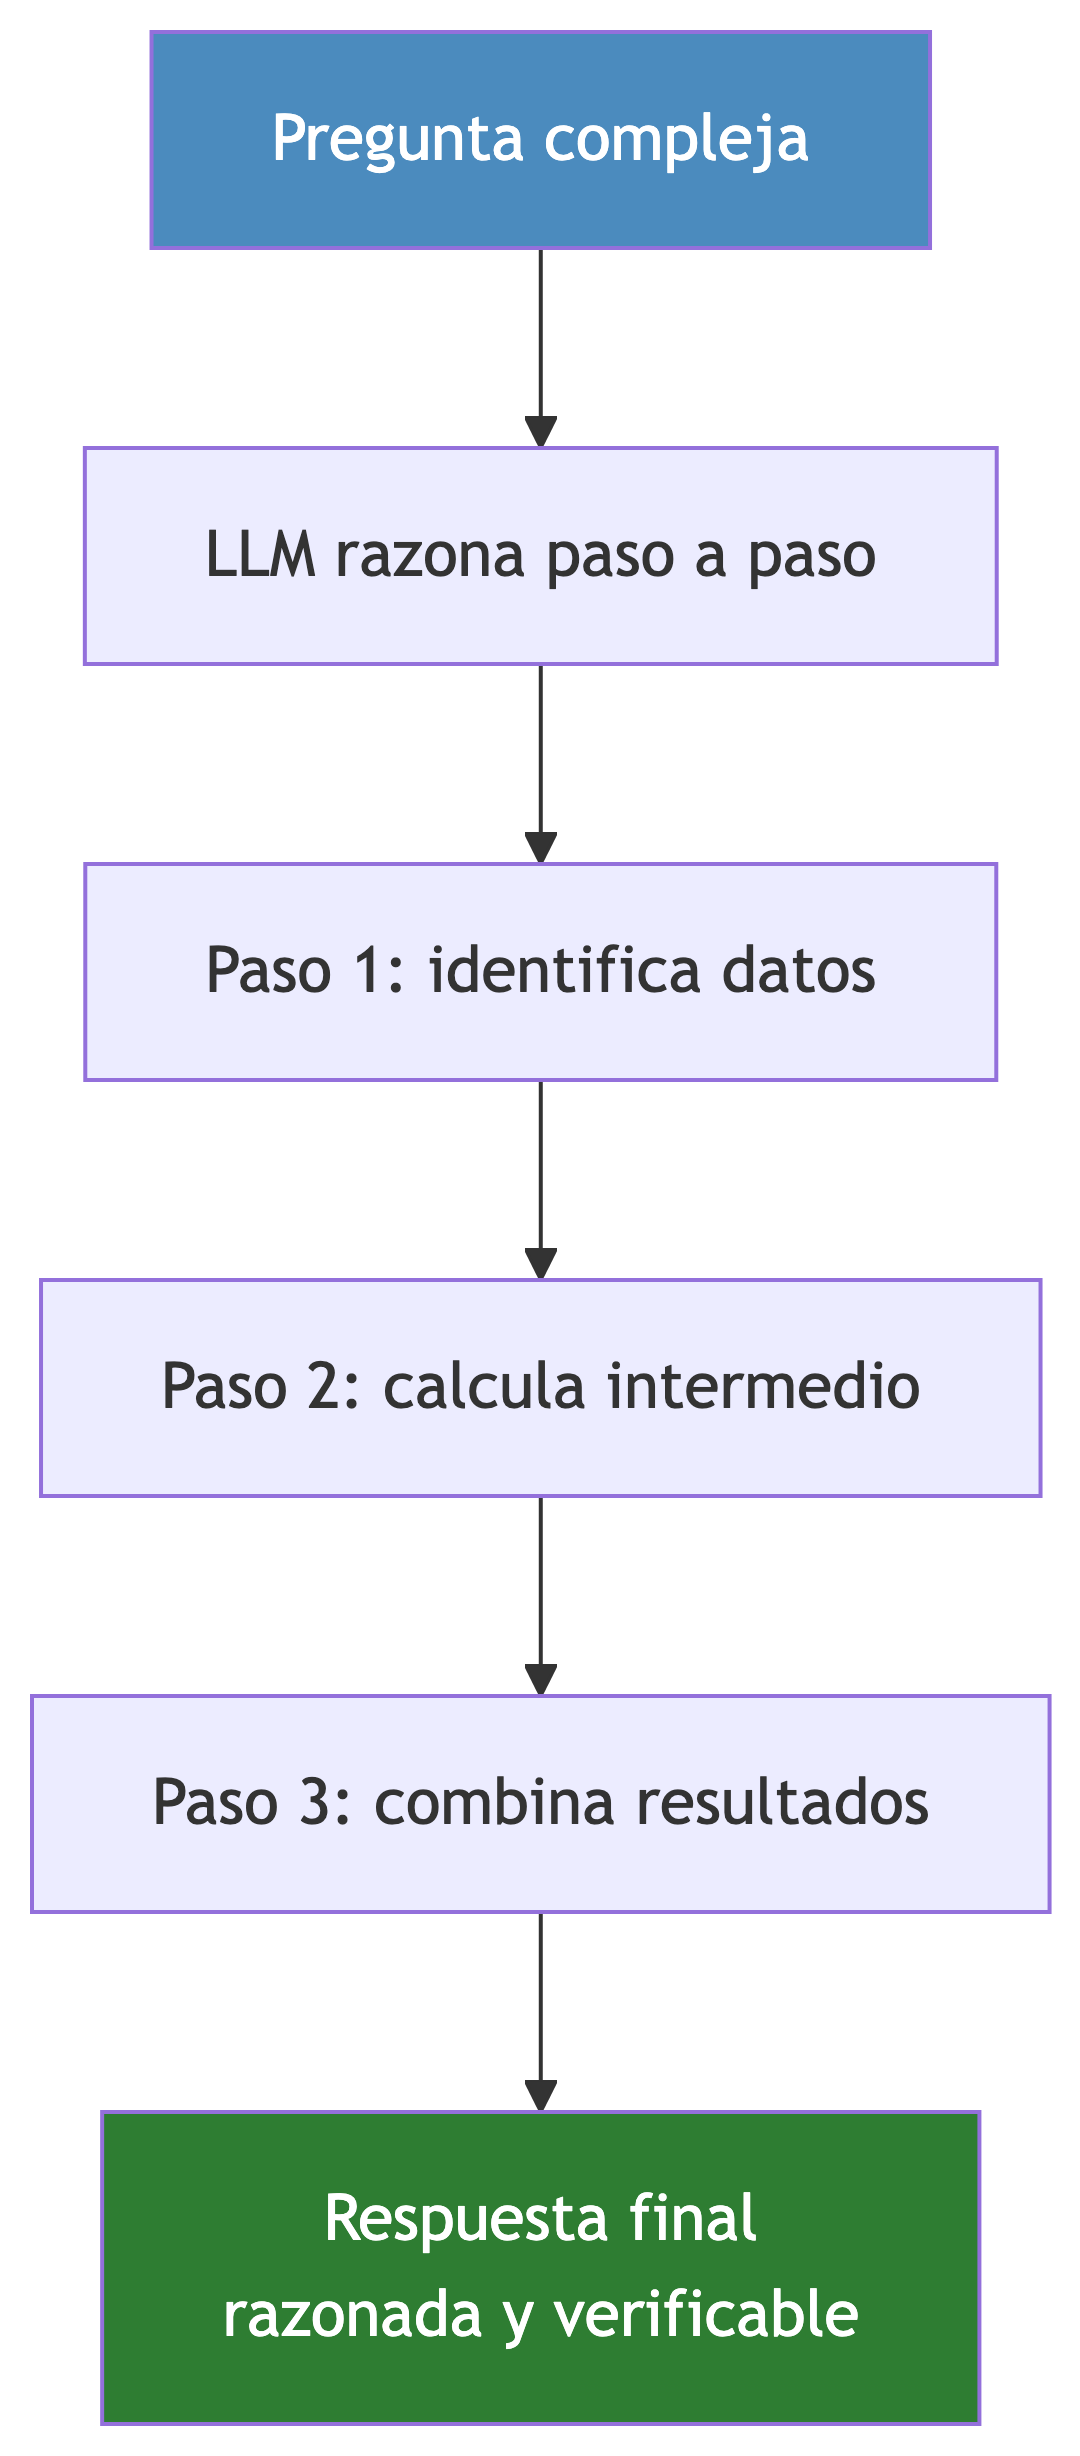
<figcaption>Figure 2</figcaption>
</figure>

**¿Por qué funciona?** Al obligar al modelo a generar tokens intermedios
de razonamiento, cada paso condiciona el siguiente. Es como si el modelo
“pensara en voz alta”, reduciendo drásticamente los errores en tareas
matemáticas y lógicas.

### Tree-of-Thought (ToT)

El **Tree-of-Thought** extiende CoT: en lugar de un único camino de
razonamiento, el modelo explora múltiples ramas y elige la mejor. Es
útil para problemas con múltiples soluciones posibles (planificación,
puzzles, creatividad).

<figure id="fig-tot">
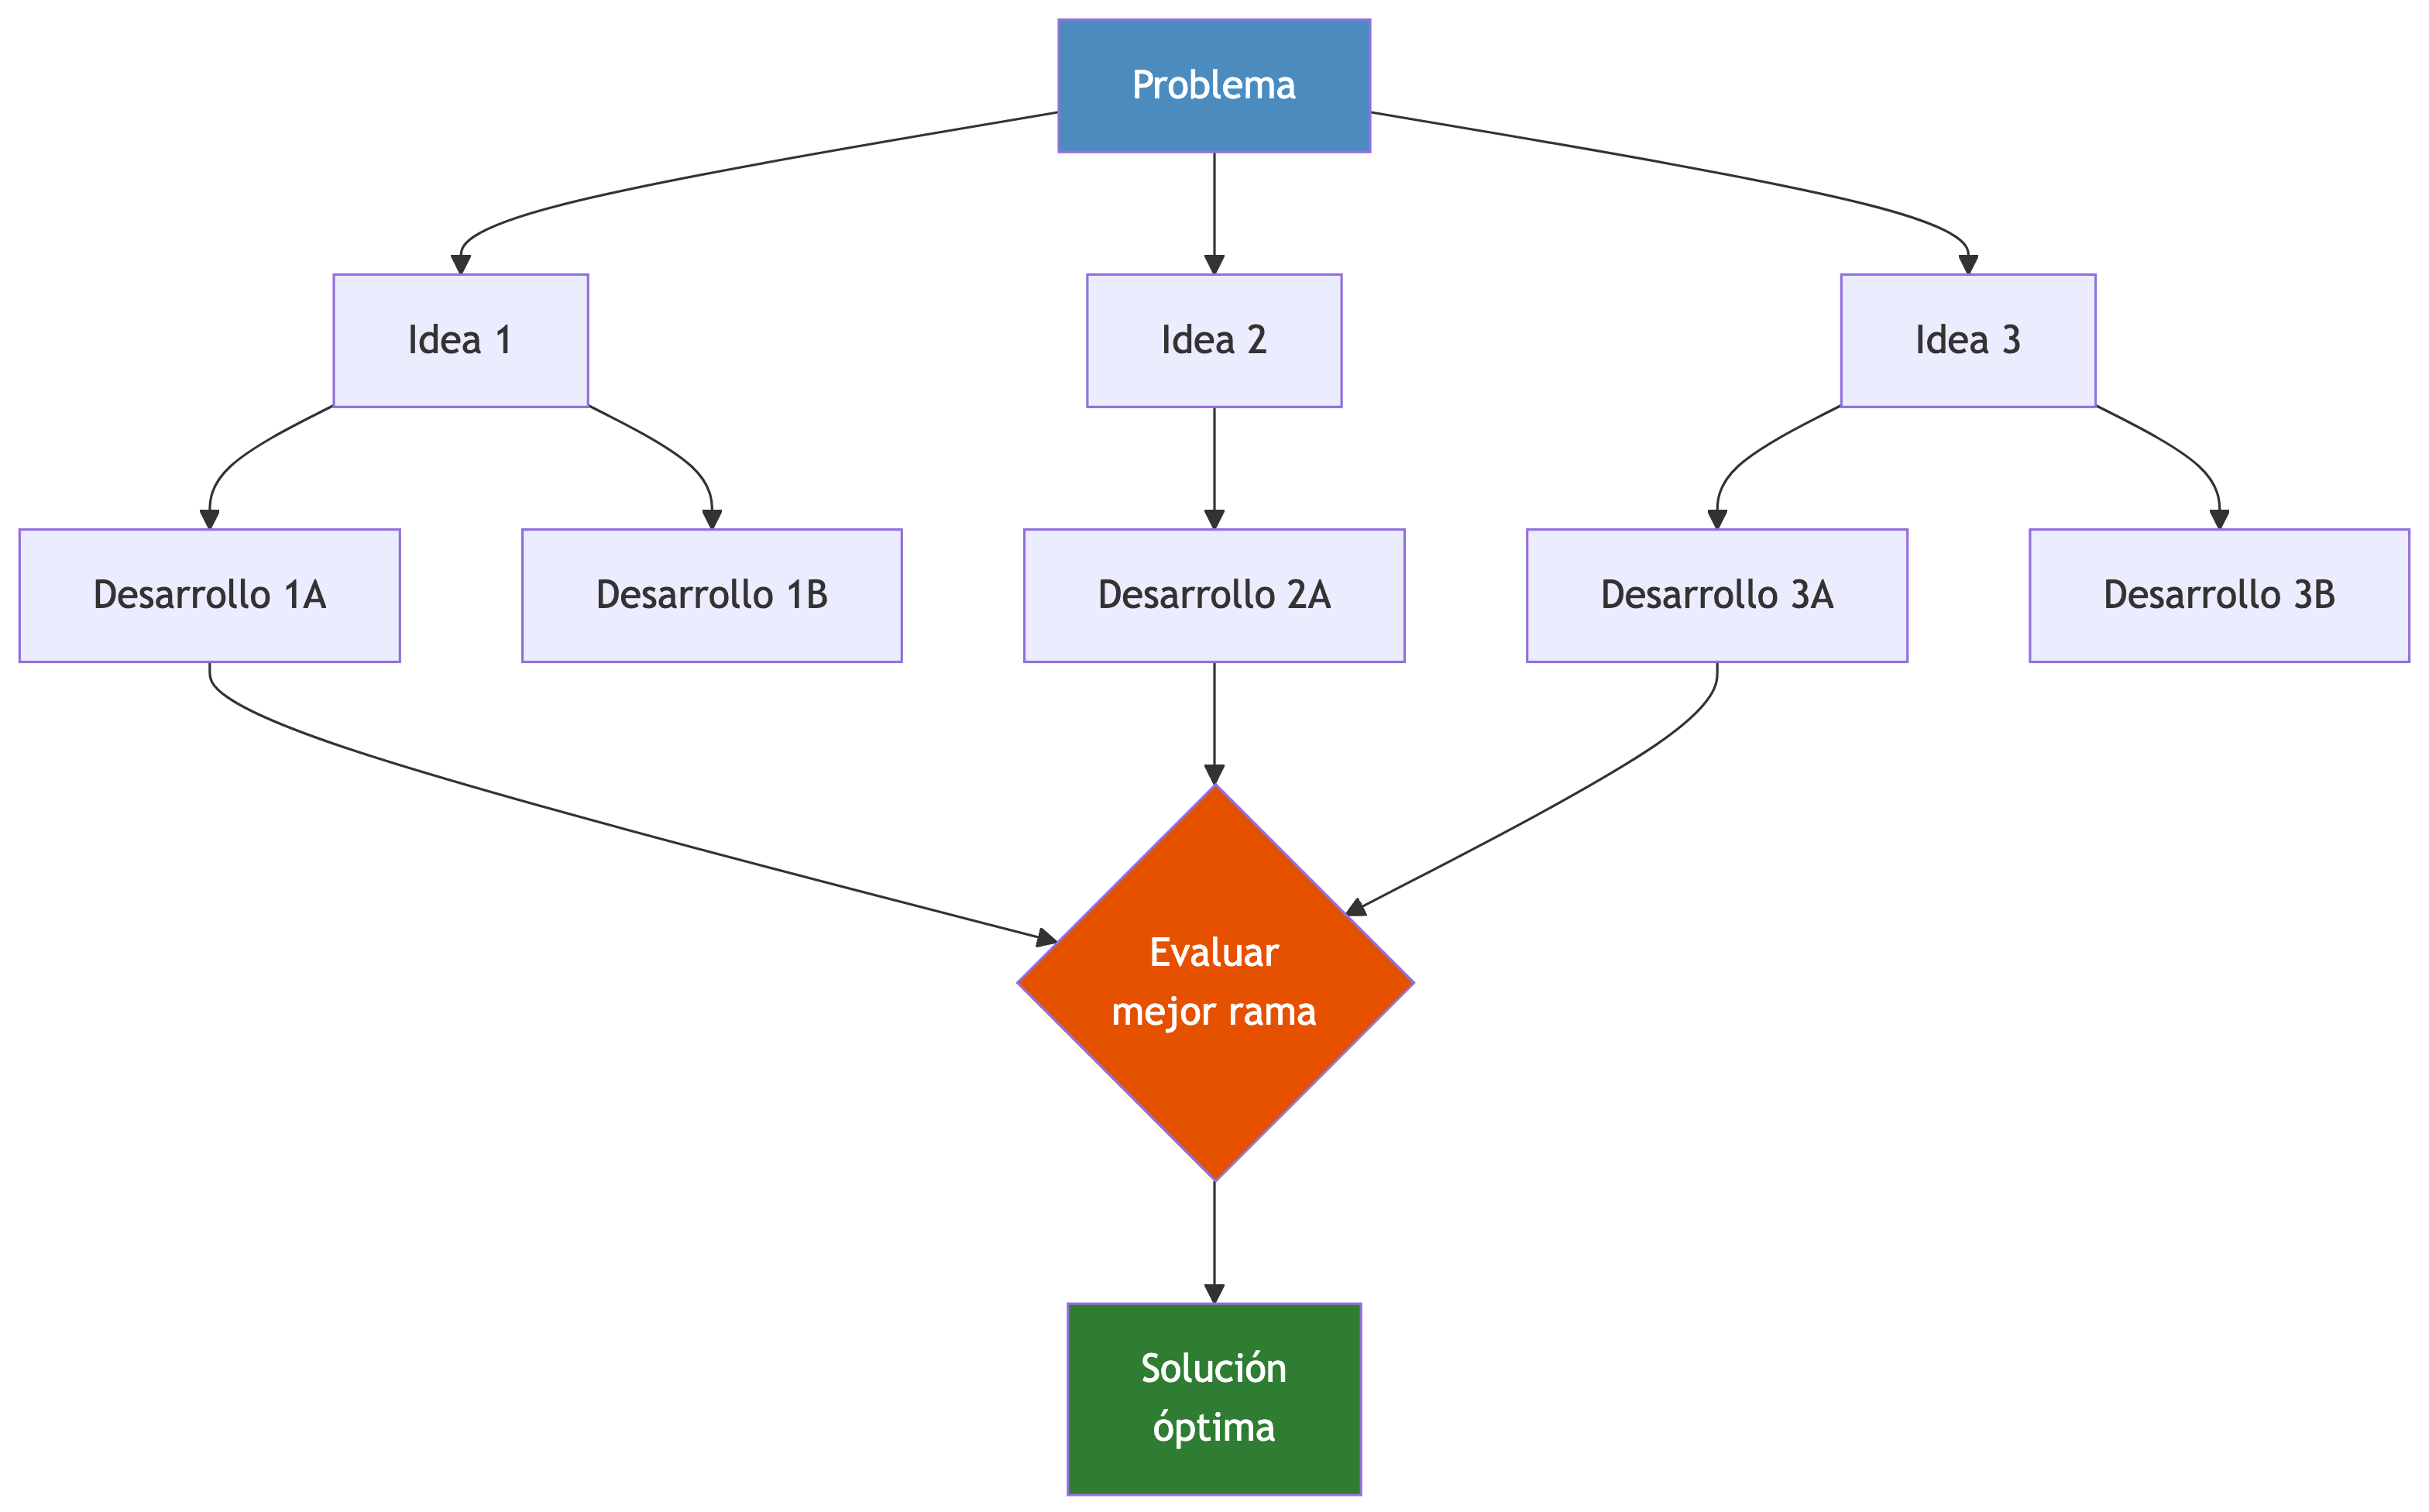
<figcaption>Figure 3</figcaption>
</figure>

In [ ]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    prompt_tot = """
    Quiero organizar una jornada de team building de 4 horas para 20 personas de un equipo de Data Science.

    Genera 3 enfoques distintos y para cada uno:
    - Describe brevemente la actividad principal
    - Evalúa pros y contras (coste, engagement, logística)
    - Elige el mejor y justifica por qué

    Al final, desarrolla en detalle solo la opción elegida.
    """

    respuesta = client.chat.completions.create(
        model="mlx-community/Qwen3.6-35B-A3B-8bit",
        messages=[{"role": "user", "content": prompt_tot}]
    )
    print(respuesta.choices[0].message.content)

> **Note**
>
> ToT requiere más tokens (y por tanto más coste) que CoT simple, ya que
> se generan y evalúan múltiples ramas. En la práctica, se implementa
> con múltiples llamadas al LLM o agentes que evalúan cada rama.

### Output Structuring con JSON Schema

Forzar que el modelo devuelva JSON nos permite integrar el LLM en
pipelines automatizados. La API de OpenAI ofrece el parámetro
`response_format` para garantizar JSON válido:

In [ ]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    texto_a_analizar = """
    Reunión del 15/03/2026. Asistentes: Ana (Data), Carlos (ML), Bea (Product).
    Se acordó migrar el pipeline ETL a Spark antes del Q2.
    Presupuesto estimado: 45.000€. Carlos se encarga de la POC.
    """

    system_prompt = f"""Eres un extractor de datos de actas de reunión.
Devuelve ÚNICAMENTE un JSON válido con esta estructura exacta, sin texto adicional:
{{
  "fecha": "string (formato YYYY-MM-DD)",
  "asistentes": ["lista de nombres"],
  "decisiones": ["lista de decisiones tomadas"],
  "presupuesto_euros": 0.0,
  "responsables": [{{"nombre": "string", "tarea": "string"}}]
}}"""

    respuesta = client.chat.completions.create(
        model="mlx-community/Qwen3.6-35B-A3B-8bit",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": texto_a_analizar}
        ],
    )

    try:
        resultado = parse_json_response(respuesta.choices[0].message.content)
        print(json.dumps(resultado, indent=2, ensure_ascii=False))
    except json.JSONDecodeError:
        print("⚠️ El modelo no devolvió JSON válido. Intenta de nuevo o usa un modelo con soporte nativo de structured output.")
        print(respuesta.choices[0].message.content[:200])

> **JSON vía prompt vs. structured output nativo**
>
> Pedir JSON en el prompt funciona con **cualquier modelo**, pero **no
> garantiza** que el JSON sea válido (por eso añadimos `try/except`).
> Algunos modelos como Qwen 3 ofrecen `response_format` nativo que
> fuerza la estructura desde el API. La ventaja del prompting es que es
> **model-agnostic**: funciona con Gemma, Llama, Mistral, etc.

### De JSON Schema a datos sintéticos: el enfoque intuitivo

Lo que acabas de hacer —extraer 1 registro JSON de un texto— es el mismo
mecanismo que permite **generar datasets sintéticos completos**. La
diferencia es de escala: en lugar de pedir 1 registro, pides N. En lugar
de extraer de un texto real, pides al modelo que *invente* datos
verosímiles.

La receta es simple:

1.  **Define el schema** de tus datos (igual que en la sección anterior)
2.  **Añade few-shot examples** para que el modelo entienda el dominio y
    los rangos esperados
3.  **Controla la diversidad** con temperatura: baja produce datos
    conservadores, alta inyecta variedad
4.  **Itera en batch** para generar cientos o miles de registros

In [ ]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    import pandas as pd

    system_prompt = """Eres un generador de datos sintéticos de clientes españoles.
Devuelve ÚNICAMENTE un JSON válido con esta estructura exacta, sin texto adicional:
{
  "clientes": [
    {
      "id": 1,
      "edad": 34,
      "ingresos_anuales": 42000.0,
      "provincia": "Madrid",
      "segmento": "premium"
    }
  ]
}
Reglas:
- Edad entre 18 y 80 años
- Ingresos entre 12000 y 120000, correlacionados con la edad
- Provincias: Madrid, Barcelona, Valencia, Sevilla, Bilbao, Málaga, Zaragoza
- Segmentos: premium, estandar, basic
- Genera variedad realista"""

    respuesta = client.chat.completions.create(
        model="mlx-community/Qwen3.6-35B-A3B-8bit",
        temperature=0.8,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": "Genera 10 clientes sintéticos. Usa variedad realista en edades, ingresos y provincias."}
        ],
    )

    try:
        datos = parse_json_response(respuesta.choices[0].message.content)
        df = pd.DataFrame(datos["clientes"])
        print(df.to_string(index=False))
        print(f"\n{len(df)} registros generados")
        print(f"   Edad: {df['edad'].min()}-{df['edad'].max()} (media {df['edad'].mean():.0f})")
        print(f"   Ingresos: {df['ingresos_anuales'].min():.0f}-{df['ingresos_anuales'].max():.0f} (media {df['ingresos_anuales'].mean():.0f})")
    except (json.JSONDecodeError, KeyError) as e:
        print(f"⚠️ Error al parsear respuesta: {e}")
        print(respuesta.choices[0].message.content[:200])

> **¿Por qué funciona?**
>
> El LLM no “conoce” clientes reales, pero ha visto millones de patrones
> en sus datos de entrenamiento: distribuciones de edad, rangos de
> ingresos típicos, provincias españolas. El **prompt con el schema**,
> el **few-shot** y la **temperatura** controlan estructura, dominio y
> diversidad. Algunos modelos (Qwen, OpenAI) ofrecen además
> `response_format` nativo para forzar la estructura desde el API.
>
> **Este es el enfoque más intuitivo y accesible para datos
> sintéticos:** - Sin entrenar modelos adicionales - Sin GPU - En menos
> de 20 líneas de código - Funciona con cualquier modelo (Gemma, Qwen,
> Llama, etc.) - Ideal para prototipado, testing y aumento rápido de
> datasets pequeños

> **Limitaciones del enfoque intuitivo**
>
> - No garantiza **correlaciones realistas** entre columnas (ej.
>   ingresos vs. edad pueden no seguir la relación esperada)
> - Puede generar **valores atípicos** no representativos
> - Depende de la **calidad del prompt** y los ejemplos
> - **No hay garantía de privacidad** diferencial
>
> Para datasets de producción donde la fidelidad estadística es crítica,
> necesitarás modelos generativos especializados (CTGAN, TVAE, TabDDPM)
> que veremos en el **Bloque 3** con SDV.

### Role Prompting

Asignar un **rol** al modelo en el mensaje `system` cambia radicalmente
su comportamiento. No es magia: el modelo, entrenado con textos de
diversos perfiles, “activa” los patrones asociados a ese rol.

In [ ]:
def consultar_como(rol, pregunta):
    return client.chat.completions.create(
        model="mlx-community/Qwen3.6-35B-A3B-8bit",
        messages=[
            {"role": "system", "content": rol},
            {"role": "user", "content": pregunta}
        ]
    ).choices[0].message.content

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    # Sin rol (genérico)
    print("=== SIN ROL ===")
    print(consultar_como("Eres un asistente útil.", "¿Qué opinas de usar la media en datos con outliers?"))

    # Con rol de analista senior
    print("\n=== ANALISTA SENIOR ===")
    print(consultar_como(
        "Eres un analista de datos senior con 15 años de experiencia en finanzas. "
        "Respondes con rigor estadístico, mencionas alternativas robustas y das ejemplos concretos.",
        "¿Qué opinas de usar la media en datos con outliers?"
    ))

    # Con rol de profesor divulgador
    print("\n=== PROFESOR DIVULGADOR ===")
    print(consultar_como(
        "Eres un profesor de estadística que explica conceptos a estudiantes de primero de carrera. "
        "Usas analogías cotidianas, evitas jerga innecesaria y pones ejemplos sencillos.",
        "¿Qué opinas de usar la media en datos con outliers?"
    ))

### Técnicas adicionales

| Técnica | Descripción | Cuándo usarla |
|------------------------|------------------------|------------------------|
| **Self-consistency** | Ejecutar CoT varias veces y votar la respuesta mayoritaria | Razonamiento matemático/lógico |
| **Generated knowledge** | Pedir al modelo que genere contexto antes de responder | Preguntas que requieren conocimiento factual |
| **Re-reading (RE2)** | Hacer que el modelo lea la pregunta dos veces | Mejora comprensión en tareas largas |
| **Emotion prompting** | Añadir estímulos emocionales al prompt | Tareas creativas o subjetivas |
| **Step-back prompting** | Preguntar primero por principios generales | Problemas muy específicos |

Table 3: Técnicas avanzadas de prompting y cuándo aplicarlas

In [ ]:
if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    prompt_step_back = """
    Pregunta original: ¿Es 17 un número primo de Mersenne?

    Antes de responder, contesta:
    1. ¿Qué es un número primo de Mersenne? (definición general)
    2. ¿Cómo se comprueba si un número es primo de Mersenne? (método)
    3. Ahora aplica el método a 17 y concluye.
    """

    print(client.chat.completions.create(
        model="mlx-community/Qwen3.6-35B-A3B-8bit",
        messages=[{"role": "user", "content": prompt_step_back}]
    ).choices[0].message.content)

### Buenas prácticas resumen

1.  **Sé específico**: “analiza los datos” → malo. “calcula media,
    mediana y desviación típica de la columna ‘ventas’ agrupada por
    ‘región’” → bueno
2.  **Muestra, no solo digas**: incluye ejemplos del formato que esperas
    (few-shot)
3.  **Divide y vencerás**: tareas complejas → CoT, desglosa en pasos
4.  **Formato forzado**: usa `response_format` / JSON Schema cuando
    integres con código
5.  **Itera**: el primer prompt casi nunca es el óptimo. Prueba,
    compara, mejora
6.  **System prompt**: define el tono, rol y restricciones al inicio

> **Lectura recomendada:** [Prompt Engineering Guide
> (DAIR.AI)](https://www.promptingguide.ai/) (DAIR.AI, 2025). Para
> técnicas específicas de razonamiento, ver también Wei et al. (2022) y
> Yao et al. (2023).

# References

DAIR.AI. (2025). *Prompt engineering guide*. Guı́a en lı́nea.
<https://www.promptingguide.ai/>

Wei, J., Wang, X., Schuurmans, D., Bosma, M., Ichter, B., Xia, F., Chi,
E. H., Le, Q. V., & Zhou, D. (2022). Chain-of-thought prompting elicits
reasoning in large language models. *Advances in Neural Information
Processing Systems*, *35*, 24824–24837.
<https://arxiv.org/abs/2201.11903>

Yao, S., Zhao, J., Yu, D., Du, N., Shafran, I., Narasimhan, K. R., &
Cao, Y. (2023). ReAct: Synergizing reasoning and acting in language
models. *International Conference on Learning Representations (ICLR)*.
<https://arxiv.org/abs/2210.03629>